In [20]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spikeinterface.full as si
from scipy.ndimage import gaussian_filter1d
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from analyse_utils import (
    flatten_array_of_arrays, extract_y_from_locations,
    gaussian_smooth_1d, gaussian_smooth_reflect_1d,
    build_profiles_for_band,
    plot_heatmap_probe, plot_random_bouts_depth_bands, plot_random_bouts_rgb_mixing,
    plot_warped_profiles
)

try:
    from config import DATA_ROOT, DB_PATH
except Exception as exc:
    print(f"Warning: unable to import config paths from config.py: {exc}")
    DATA_ROOT = Path("F:/Data_Mice_IBL")
    DB_PATH = Path(r"F:\Data_Mice_IBL\full_db_all_rigs.feather")

In [21]:
# ==========================================================
# === MASTER CONFIGURATION ================================
# ==========================================================

# -------- PROBE SELECTION --------
PROBE = "probe00"  # Change to "probe00" or "probe01"

# -------- session parameters --------
MOUSE = "VF074"
MOUSE_BEHAVIOR = "VF074"
DATE = "2026_03_24"

# -------- file paths (auto-generated from probe selection) --------
BASE_FOLDER = DATA_ROOT / MOUSE / DATE
REC_FOLDER = BASE_FOLDER / "Rec" / PROBE
ANALYZER_FOLDER = BASE_FOLDER / "sorting_analyzer" / PROBE
BOMBCELL_CSV = BASE_FOLDER / "bombcell" / PROBE / "bombcell_labels.csv"
AFFINE_PATH = BASE_FOLDER / "shift" / PROBE / "alignment_affine.json"
LF_CBIN_PATH = REC_FOLDER / f"disabled_g0_t0.imec0.lf.cbin"
AP_CBIN_PATH = REC_FOLDER / f"disabled_g0_t0.imec0.ap.cbin"

# -------- general parameters --------
T_START = None  # None = auto from spike times
T_STOP = None   # None = auto from spike times
RANDOM_SEED = 42

# -------- heatmap parameters --------
HEATMAP_TIME_BIN_S = 1
HEATMAP_DEPTH_BIN_UM = 40
HEATMAP_SMOOTH_SIGMA_TIME = 1.0
HEATMAP_SMOOTH_SIGMA_DEPTH = 1.0
HEATMAP_SMOOTH_SIGMA_SPIKE_DENSITY = 1.5

# -------- band parameters (shared across plots) --------
DEPTH_BAND_1 = (0.0, 1000.0)
DEPTH_BAND_2 = (1000.0, 2000.0)
DEPTH_BAND_3 = (2000.0, np.inf)

BAND_NAME_1 = "0–1000 µm"
BAND_NAME_2 = "1000–2000 µm"
BAND_NAME_3 = ">2000 µm (MOs)"

COLOR_BAND_1 = "#DC2626"  # red
COLOR_BAND_2 = "#D97706"  # orange
COLOR_BAND_3 = "#2563EB"  # blue
STD_COLOR_BAND_3 = "#93C5FD"

# -------- bout plot parameters --------
N_BOUTS_TO_PLOT = 5
BOUT_COLOR = "#4FC3F7"
REWARDED_COLOR = "green"
NONREWARDED_COLOR = "red"

# -------- start/first lick/end lick colors --------
START_COLOR = "#06B6D4"
FIRSTLICK_COLOR = "#16A34A"
ENDLICK_COLOR = "#7C3AED"

# -------- background colors --------
BG_PRE = "#F8FAFC"
BG_MID1 = "#ECFDF5"
BG_MID2 = "#EEF2FF"
BG_POST = "#F8FAFC"

# -------- global curves parameters --------
GLOBAL_CURVE_COLOR = "black"

# -------- single-bout parameters --------
SINGLEBOUT_PRE_TIME = 5
SINGLEBOUT_POST_TIME = 5
SINGLEBOUT_BIN_SIZE = 0.05
SINGLEBOUT_SMOOTH_SIGMA = 2
SINGLEBOUT_DEPTH_BIN_UM = 100
SINGLEBOUT_SMOOTH_SIGMA_DEPTH_TIME = 2
SINGLEBOUT_SELECT_MODE = "most_licks"  # "random", "most_licks", "longest"

# -------- random bouts parameters --------
RAMBOUTS_T_BEFORE = 3
RAMBOUTS_T_AFTER = 3
RAMBOUTS_TIME_BIN_S = 0.05
RAMBOUTS_SMOOTH_SIGMA_CURVE = 0.5

# -------- RGB mixing parameters --------
RGBMIX_T_BEFORE = 5.0
RGBMIX_T_AFTER = 5.0
RGBMIX_TIME_BIN_S = 0.025
RGBMIX_SMOOTH_SIGMA_CURVE = 1

# -------- warped profiles parameters --------
WARPED_PRE_WINDOW_S = 3.0
WARPED_POST_WINDOW_S = 3.0
WARPED_TIME_BIN_S = 0.1
WARPED_SMOOTH_SIGMA = 1.4
WARPED_N_BINS_START_TO_FIRST = 35
WARPED_N_BINS_FIRST_TO_LAST = 100

print("=" * 60)
print("CONFIGURATION LOADED")
print("=" * 60)
print(f"Probe: {PROBE}")
print(f"Mouse: {MOUSE}")
print(f"Date: {DATE}")
print(f"Data root: {BASE_FOLDER}")


CONFIGURATION LOADED
Probe: probe00
Mouse: VF074
Date: 2026_03_24
Data root: F:\Data_Mice_IBL\VF074\2026_03_24


In [22]:
# ==========================================================
# === LOAD COMMON DATA ====================================
# ==========================================================

print("\n" + "=" * 60)
print("LOADING DATA")
print("=" * 60)

# Load alignment
with open(AFFINE_PATH, "r", encoding="utf-8") as f:
    affine = json.load(f)

affine_a = float(affine["a"])
affine_b = float(affine["b"])
print(f"Alignment: t_behavior = {affine_a:.8f} * t_ephys + {affine_b:.8f}")

# Load behavior data
date_str = f"{DATE[:4]}-{DATE[5:7]}-{DATE[8:10]}"
df = pd.read_feather(DB_PATH)
row = df[(df["Mouse_ID"] == MOUSE_BEHAVIOR) & (df["Date"] == date_str)]

if len(row) == 0:
    raise ValueError(f"No behavior entry found for {MOUSE_BEHAVIOR} / {date_str}")

row = row.iloc[0]

bout_starts = np.asarray(row["Bout Start Times"], dtype=float)
correct_bouts = np.asarray(row["Correct Bouts"], dtype=bool)
time_first_lick = np.asarray(row["Time First Lick"], dtype=float)
time_last_lick = np.asarray(row["Time Last Lick"], dtype=float)

lick_rewarded = flatten_array_of_arrays(row["Times Rewarded Licks"])
lick_nonrewarded = flatten_array_of_arrays(row["Times Non Rewarded Licks"])
lick_invalid = flatten_array_of_arrays(row["Times Invalid Licks"])

# Load analyzer and spikes
analyzer = si.load_sorting_analyzer(ANALYZER_FOLDER)
sorting = analyzer.sorting

unit_ids_all = np.asarray(sorting.unit_ids)
spike_vector = sorting.to_spike_vector()
spike_samples = spike_vector["sample_index"]
spike_unit_indices = spike_vector["unit_index"]

rec_ap = si.read_cbin_ibl(
    folder_path=REC_FOLDER,
    cbin_file_path=AP_CBIN_PATH,
    load_sync_channel=False,
    stream_name="ap",
)

fs_ap = rec_ap.get_sampling_frequency()
spike_times_ephys = spike_samples / fs_ap
spike_times_beh = affine_a * spike_times_ephys + affine_b

# Load spike depths
spike_locations = analyzer.get_extension("spike_locations").get_data()
spike_depths = extract_y_from_locations(spike_locations, name="spike_locations")

# Filter good units if available
good_unit_ids = None
if BOMBCELL_CSV.exists():
    labels = pd.read_csv(BOMBCELL_CSV, index_col=0)
    if "bombcell_label" in labels.columns:
        good_unit_ids = labels.index[labels["bombcell_label"] == "good"].astype(int).to_numpy()
        good_mask = np.isin(unit_ids_all[spike_unit_indices], good_unit_ids)
        spike_times_beh_filtered = spike_times_beh[good_mask]
        spike_depths_filtered = spike_depths[good_mask]
        spike_unit_indices_filtered = spike_unit_indices[good_mask]
        print(f"Good units from Bombcell: {len(good_unit_ids)}")
        print(f"Spikes kept: {len(spike_times_beh_filtered)}")
else:
    spike_times_beh_filtered = spike_times_beh
    spike_depths_filtered = spike_depths
    spike_unit_indices_filtered = spike_unit_indices
    print("No Bombcell filter, using all spikes")

# Valid bouts after filtering
valid_bout_mask = correct_bouts
valid_bout_starts = bout_starts[valid_bout_mask]
valid_first_licks = time_first_lick[valid_bout_mask]
valid_last_licks = time_last_lick[valid_bout_mask]

valid_mask = (
    np.isfinite(valid_bout_starts)
    & np.isfinite(valid_first_licks)
    & np.isfinite(valid_last_licks)
    & (valid_first_licks > valid_bout_starts)
    & (valid_last_licks > valid_first_licks)
)

valid_bout_starts = valid_bout_starts[valid_mask]
valid_first_licks = valid_first_licks[valid_mask]
valid_last_licks = valid_last_licks[valid_mask]

print(f"\nBehavior:")
print(f"  Total bouts: {len(bout_starts)}")
print(f"  Valid bouts: {len(valid_bout_starts)}")
print(f"  Rewarded licks: {len(lick_rewarded)}")
print(f"  Non-rewarded licks: {len(lick_nonrewarded)}")
print(f"  Total spikes (filtered): {len(spike_times_beh_filtered)}")
print(f"  Spike depth range: {spike_depths_filtered.min():.1f} - {spike_depths_filtered.max():.1f} µm")



LOADING DATA
Alignment: t_behavior = 1.00001609 * t_ephys + -6.73659817
Good units from Bombcell: 142
Spikes kept: 2598357

Behavior:
  Total bouts: 135
  Valid bouts: 100
  Rewarded licks: 252
  Non-rewarded licks: 578
  Total spikes (filtered): 2598357
  Spike depth range: 24.6 - 3143.2 µm



PLOTTING HEATMAPS


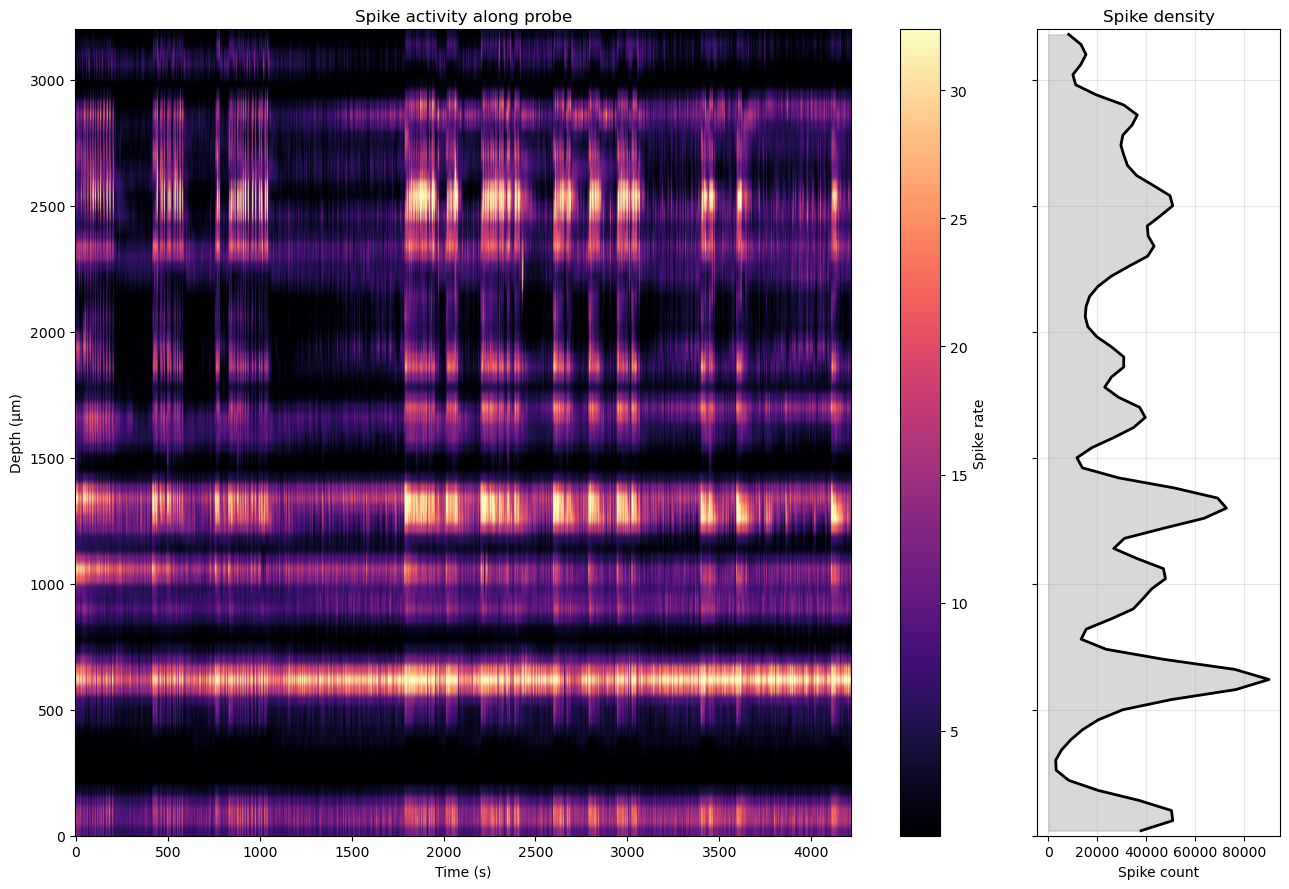

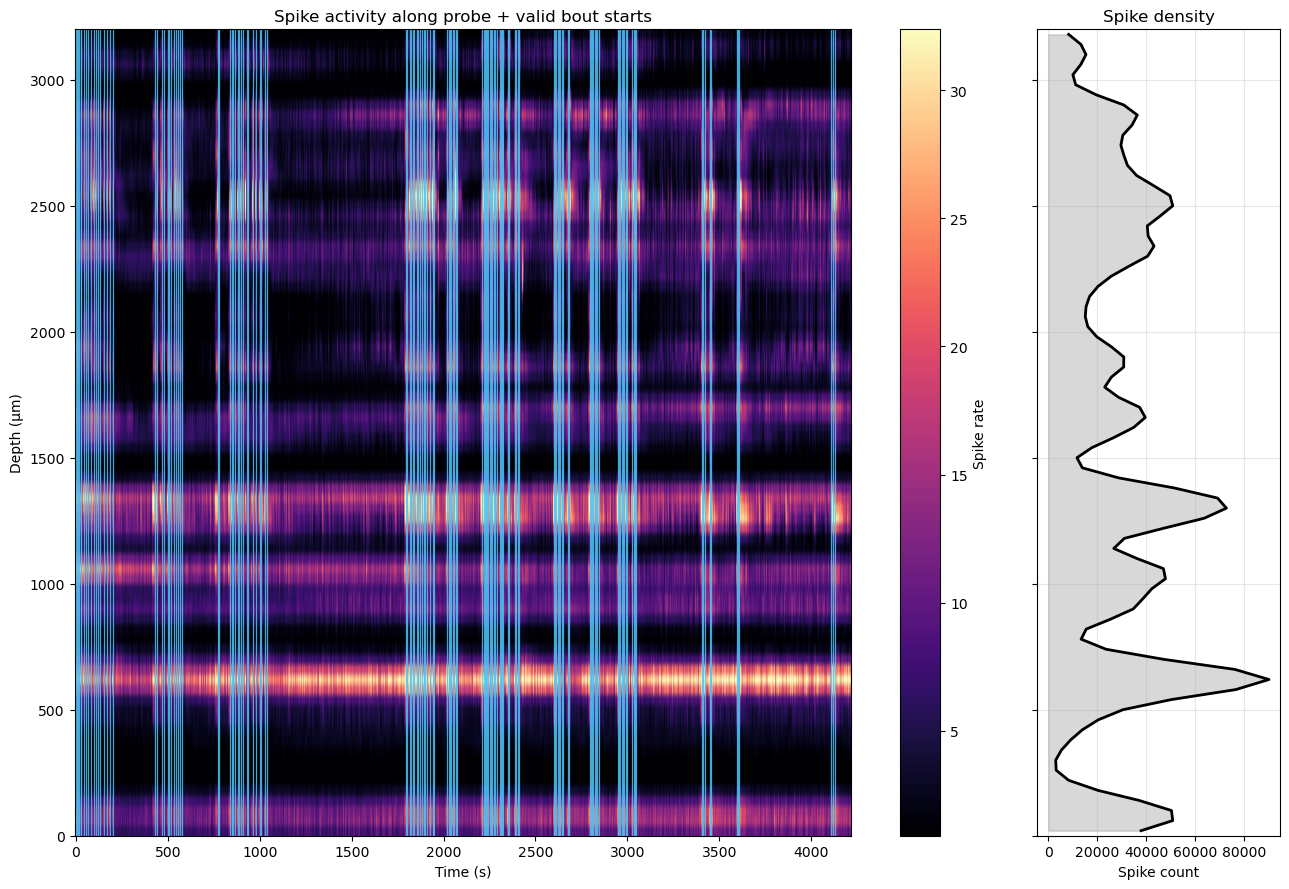

In [23]:
# ==========================================================
# === PLOT 1: HEATMAPS ====================================
# ==========================================================

print("\n" + "=" * 60)
print("PLOTTING HEATMAPS")
print("=" * 60)

# Window selection
t_start = T_START if T_START is not None else float(np.min(spike_times_beh_filtered))
t_stop = T_STOP if T_STOP is not None else float(np.max(spike_times_beh_filtered))

mask = (
    (spike_times_beh_filtered >= t_start) &
    (spike_times_beh_filtered <= t_stop) &
    np.isfinite(spike_depths_filtered)
)

spike_times_plot = spike_times_beh_filtered[mask]
spike_depths_plot = spike_depths_filtered[mask]
bout_times_plot = bout_starts[(bout_starts >= t_start) & (bout_starts <= t_stop)]

if len(spike_times_plot) == 0:
    raise ValueError("No spikes in selected time window")

# Build heatmap
depth_min = np.floor(np.min(spike_depths_plot) / HEATMAP_DEPTH_BIN_UM) * HEATMAP_DEPTH_BIN_UM
depth_max = np.ceil(np.max(spike_depths_plot) / HEATMAP_DEPTH_BIN_UM) * HEATMAP_DEPTH_BIN_UM + HEATMAP_DEPTH_BIN_UM

time_bins = np.arange(t_start, t_stop + HEATMAP_TIME_BIN_S, HEATMAP_TIME_BIN_S)
depth_bins = np.arange(depth_min, depth_max + HEATMAP_DEPTH_BIN_UM, HEATMAP_DEPTH_BIN_UM)

heatmap_counts, _, _ = np.histogram2d(
    spike_depths_plot,
    spike_times_plot,
    bins=[depth_bins, time_bins],
)

heatmap = heatmap_counts / HEATMAP_TIME_BIN_S
heatmap = gaussian_smooth_1d(heatmap, HEATMAP_SMOOTH_SIGMA_DEPTH, axis=0)
heatmap = gaussian_smooth_1d(heatmap, HEATMAP_SMOOTH_SIGMA_TIME, axis=1)

depth_centers = 0.5 * (depth_bins[:-1] + depth_bins[1:])

spike_density, _ = np.histogram(spike_depths_plot, bins=depth_bins)
spike_density_smooth = gaussian_smooth_1d(
    spike_density.astype(float),
    sigma=HEATMAP_SMOOTH_SIGMA_SPIKE_DENSITY,
    axis=0
)

# Plot heatmap without bout markers
plot_heatmap_probe(
    heatmap=heatmap,
    time_bins=time_bins,
    depth_bins=depth_bins,
    spike_density_smooth=spike_density_smooth,
    depth_centers=depth_centers,
    bout_times=None,
    bout_color=BOUT_COLOR,
    title="Spike activity along probe",
)

# Plot heatmap with bout starts
plot_heatmap_probe(
    heatmap=heatmap,
    time_bins=time_bins,
    depth_bins=depth_bins,
    spike_density_smooth=spike_density_smooth,
    depth_centers=depth_centers,
    bout_times=bout_times_plot,
    bout_color=BOUT_COLOR,
    title="Spike activity along probe + valid bout starts",
)



PLOTTING RANDOM BOUTS - DEPTH BANDS
Global z-score stats (depth bands):
  0–1000 µm: mu=196.352, sigma=100.410
  1000–2000 µm: mu=216.637, sigma=128.778
  >2000 µm (MOs): mu=201.854, sigma=155.740


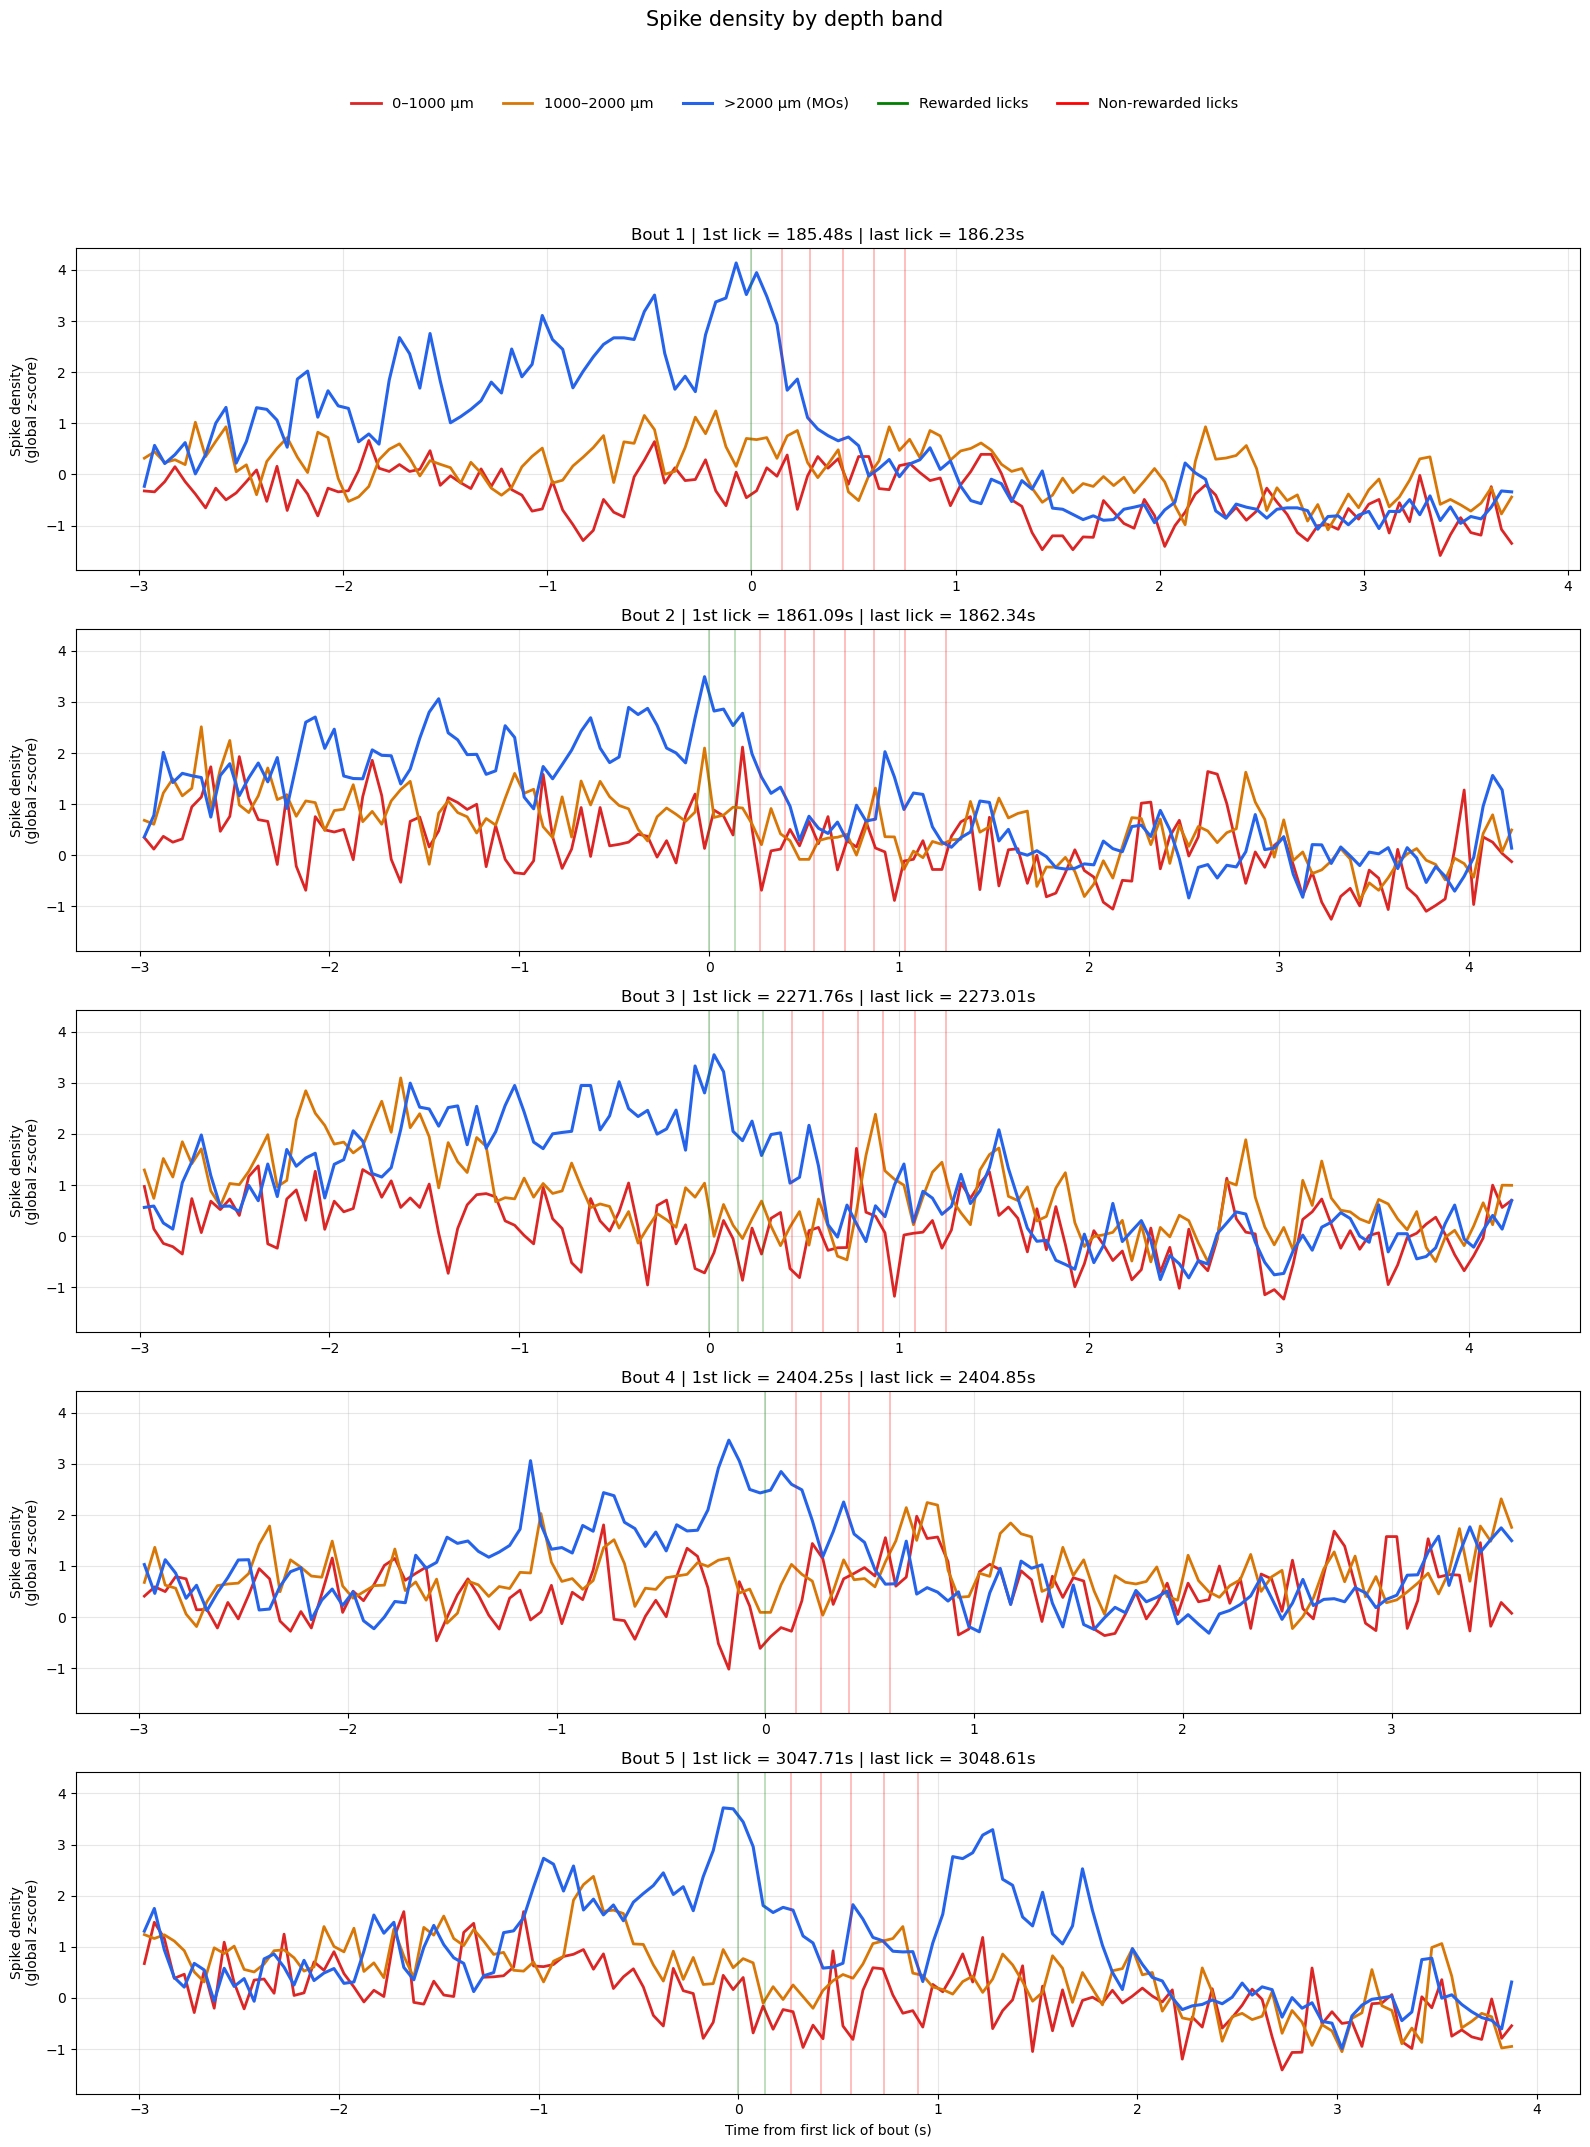

In [24]:
# ==========================================================
# === PLOT 2: RANDOM BOUTS - DEPTH BANDS ==================
# ==========================================================

print("\n" + "=" * 60)
print("PLOTTING RANDOM BOUTS - DEPTH BANDS")
print("=" * 60)

plot_random_bouts_depth_bands(
    spike_times_beh_filtered, spike_depths_filtered, bout_starts, lick_rewarded, lick_nonrewarded,
    valid_bout_starts, DEPTH_BAND_1, DEPTH_BAND_2, DEPTH_BAND_3,
    BAND_NAME_1, BAND_NAME_2, BAND_NAME_3,
    COLOR_BAND_1, COLOR_BAND_2, COLOR_BAND_3,
    REWARDED_COLOR, NONREWARDED_COLOR,
    N_BOUTS_TO_PLOT, RANDOM_SEED,
    RAMBOUTS_T_BEFORE, RAMBOUTS_T_AFTER, RAMBOUTS_TIME_BIN_S, RAMBOUTS_SMOOTH_SIGMA_CURVE
)



PLOTTING RANDOM BOUTS - RGB MIXING
Global z-score stats (RGB mixing):
  0–1000 µm: mu=196.353, sigma=121.321
  1000–2000 µm: mu=216.638, sigma=143.601
  >2000 µm (MOs): mu=201.855, sigma=167.068


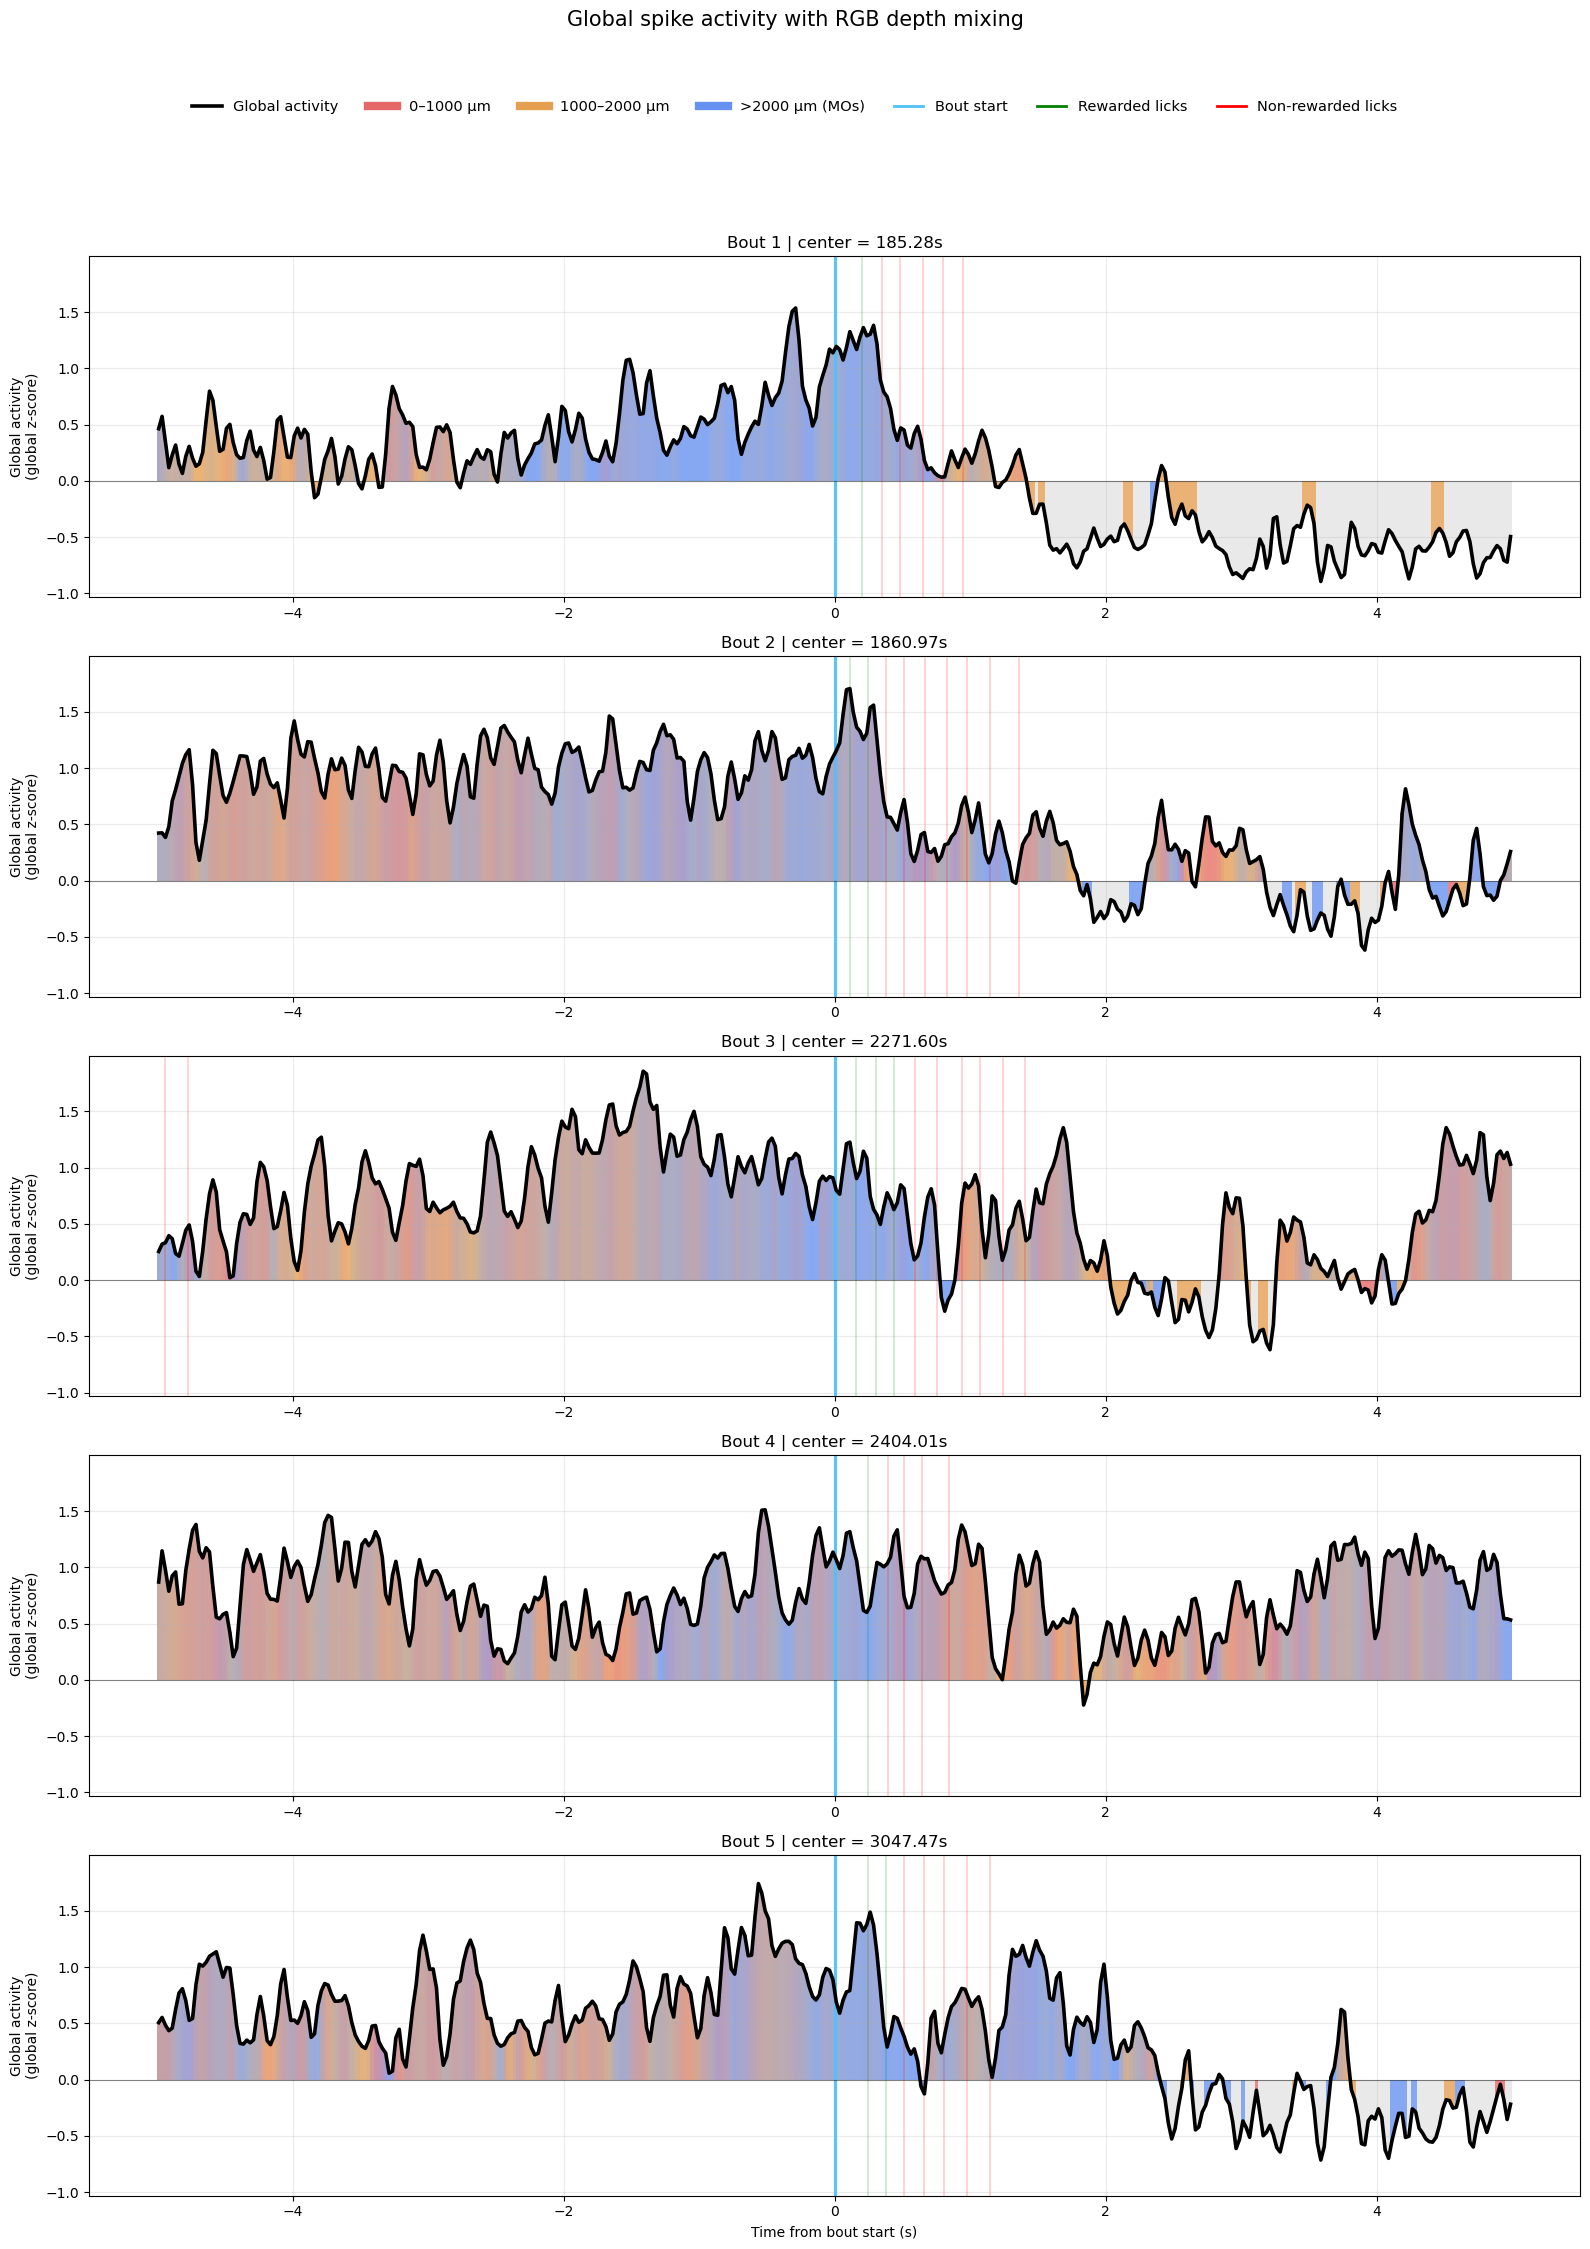

In [25]:
# ==========================================================
# === PLOT 3: RANDOM BOUTS - RGB MIXING ===================
# ==========================================================

print("\n" + "=" * 60)
print("PLOTTING RANDOM BOUTS - RGB MIXING")
print("=" * 60)

plot_random_bouts_rgb_mixing(
    spike_times_beh_filtered, spike_depths_filtered, bout_starts, lick_rewarded, lick_nonrewarded,
    valid_bout_starts, DEPTH_BAND_1, DEPTH_BAND_2, DEPTH_BAND_3,
    BAND_NAME_1, BAND_NAME_2, BAND_NAME_3,
    COLOR_BAND_1, COLOR_BAND_2, COLOR_BAND_3,
    REWARDED_COLOR, NONREWARDED_COLOR, BOUT_COLOR, GLOBAL_CURVE_COLOR,
    N_BOUTS_TO_PLOT, RANDOM_SEED,
    RGBMIX_T_BEFORE, RGBMIX_T_AFTER, RGBMIX_TIME_BIN_S, RGBMIX_SMOOTH_SIGMA_CURVE
)



PLOTTING WARPED PROFILES
Building warped profiles...
Bouts used: 100 (band1), 100 (band2), 100 (band3)


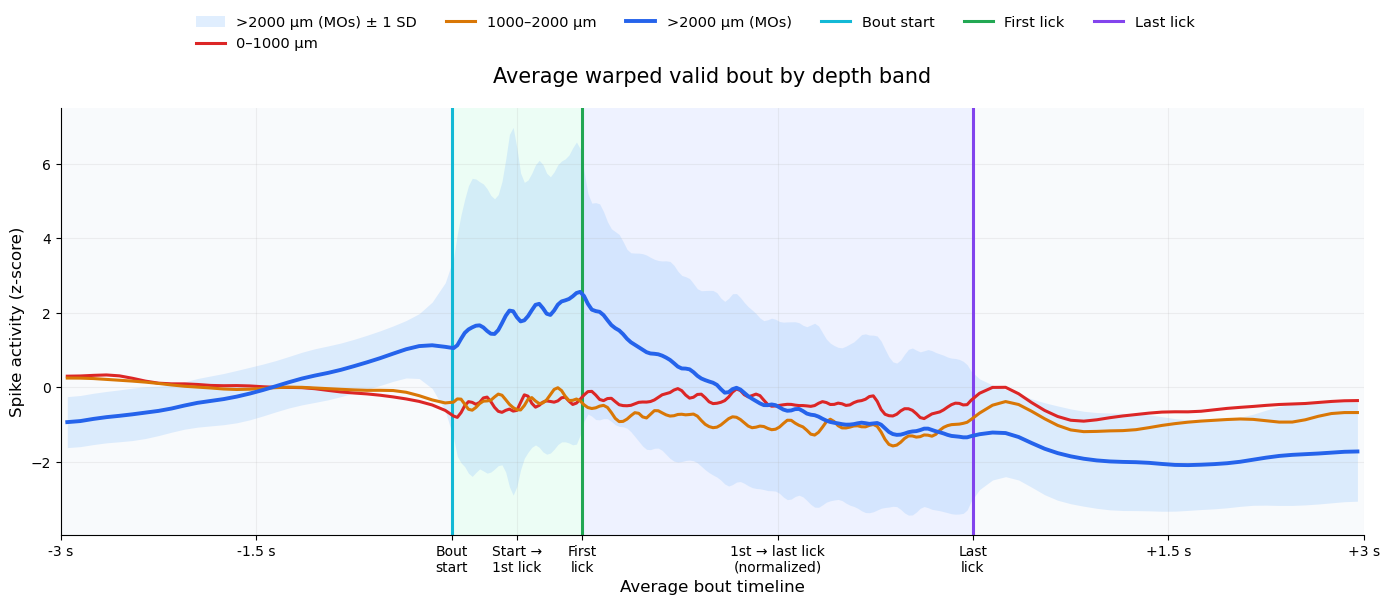

In [26]:
# ==========================================================
# === PLOT 4: WARPED PROFILES BY DEPTH BAND ================
# ==========================================================

print("\n" + "=" * 60)
print("PLOTTING WARPED PROFILES")
print("=" * 60)

plot_warped_profiles(
    spike_times_beh_filtered, spike_depths_filtered,
    valid_bout_starts, valid_first_licks, valid_last_licks,
    DEPTH_BAND_1, DEPTH_BAND_2, DEPTH_BAND_3,
    BAND_NAME_1, BAND_NAME_2, BAND_NAME_3,
    COLOR_BAND_1, COLOR_BAND_2, COLOR_BAND_3, STD_COLOR_BAND_3,
    START_COLOR, FIRSTLICK_COLOR, ENDLICK_COLOR,
    BG_PRE, BG_MID1, BG_MID2, BG_POST,
    WARPED_PRE_WINDOW_S, WARPED_POST_WINDOW_S, WARPED_TIME_BIN_S,
    WARPED_SMOOTH_SIGMA, WARPED_N_BINS_START_TO_FIRST, WARPED_N_BINS_FIRST_TO_LAST
)
